In [ ]:
from os import mkdir, path
import shutil

if not path.exists('data'):
  !git clone https://github.com/werywjw/data.git

from google.colab import drive
drive.mount('/content/drive')

In [5]:
!pip install torchinfo

import os
import pprint
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms
from matplotlib import pyplot as plt
import pandas as pd
from tqdm import tqdm
from torchinfo import summary
import numpy as np
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: mps
Running class_weights_ADAMW experiment
{'apply_class_weight': True,
 'optimizer': 'adam_optimizer',
 'dataset': 'GiMeFive',
 'hyperparameters': {'num_epochs': 80,
                     'batch_size': 16,
                     'learning_rate': 0.001,
                     'weight_decay': 0.0001}}


In [ ]:
datasets = {
    "GiMeFive": {
        "train": {
            "images": "./data/train/",
            "labels": "./data/train_labels.csv",
        },
        "validation": {
            "images": "./data/valid/",
            "labels": "./data/valid_labels.csv",
        },
        "test": {
            "images": "./data/test/",
            "labels": "./data/test_labels.csv",
        },
    },
}

experiments = {
    "baseline": {
        "apply_class_weight": False,
        "optimizer": "sgd_optimizer",
        "dataset": "GiMeFive",
        "hyperparameters": {
            "num_epochs": 80,
            "batch_size": 16,
            "learning_rate": 1e-3,
            "weight_decay": 1e-4,
            "momentum": 0.9,
        },
    },
    "class_weights_SGD": {
        "apply_class_weight": True,
        "optimizer": "sgd_optimizer",
        "dataset": "GiMeFive",
        "hyperparameters": {
            "num_epochs": 80,
            "batch_size": 16,
            "learning_rate": 1e-3,  # 0.001
            "weight_decay": 1e-4,
            "momentum": 0.9,
        },
    },
    "class_weights_ADAM": {
        "apply_class_weight": True,
        "optimizer": "adam_optimizer",
        "dataset": "GiMeFive",
        "hyperparameters": {
            "num_epochs": 80,
            "batch_size": 16,
            "learning_rate": 1e-3,
            "weight_decay": 1e-4,
        },
    },
    "class_weights_ADAMW": {
        "apply_class_weight": True,
        "optimizer": "adamw_optimizer",
        "dataset": "GiMeFive",
        "hyperparameters": {
            "num_epochs": 80,
            "batch_size": 16,
            "learning_rate": 1e-3,
            "weight_decay": 1e-4,
        },
    },
    "class_weights_ADAMW_1": {
        "apply_class_weight": True,
        "optimizer": "adamw_optimizer",
        "dataset": "GiMeFive",
        "hyperparameters": {
            "num_epochs": 80,
            "batch_size": 16,
            "learning_rate": 1e-3,
            "weight_decay": 1e-4,
            "dropout1": 0.3,
            "conv5_filters": 768,
            "fc1_input": 768,
            "fc1_output": 1024,
            "fc2_output": 512,
        },
    },
}

output_path = "/content/drive/MyDrive/Colab Notebooks/SEP-CVDL/outputs"

# Change the experiment only
experiment_name = "class_weights_ADAMW_1"

configuration = experiments[experiment_name]
dataset = datasets[configuration["dataset"]]
hyperparameters = configuration["hyperparameters"]

print(f"Running {experiment_name} experiment")


In [ ]:
class GiMeFiveDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_name = os.path.join(self.img_dir, self.labels.iloc[idx, 0])
        image = Image.open(img_name)
        label = self.labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)

        return image, label


In [6]:
transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = GiMeFiveDataset(
    csv_file=dataset["train"]["labels"],
    img_dir=dataset["train"]["images"],
    transform=transform,
)
train_data_loader = DataLoader(
    train_dataset, batch_size=hyperparameters["batch_size"], shuffle=True, num_workers=2
)
train_image, train_label = next(iter(train_data_loader))
print(f"Train batch: image shape {train_image.shape}, labels shape {train_label.shape}")

validation_dataset = GiMeFiveDataset(
    csv_file=dataset["validation"]["labels"],
    img_dir=dataset["validation"]["images"],
    transform=transform,
)
validation_data_loader = DataLoader(
    validation_dataset,
    batch_size=hyperparameters["batch_size"],
    shuffle=False,
    num_workers=0,
)
validation_image, validation_label = next(iter(validation_data_loader))
print(
    f"Validation batch: image shape {validation_image.shape}, labels shape {validation_label.shape}"
)

test_dataset = GiMeFiveDataset(
    csv_file=dataset["test"]["labels"],
    img_dir=dataset["test"]["images"],
    transform=transform,
)

test_data_loader = DataLoader(
    test_dataset, batch_size=hyperparameters["batch_size"], shuffle=False, num_workers=0
)

test_image, test_label = next(iter(test_data_loader))
print(f"Test batch: image shape {test_image.shape}, labels shape {test_label.shape}")

Train batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Validation batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Test batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])


In [7]:
class EmotionClassifier(nn.Module):
    def __init__(self):
        super(EmotionClassifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.conv5 = nn.Conv2d(
            512, hyperparameters["conv5_filters"], kernel_size=3, padding=1
        )
        self.bn5 = nn.BatchNorm2d(hyperparameters["conv5_filters"])

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(
            hyperparameters["fc1_input"], hyperparameters["fc1_output"]
        )
        self.fc2 = nn.Linear(
            hyperparameters["fc1_output"], hyperparameters["fc2_output"]
        )
        self.dropout1 = nn.Dropout(hyperparameters["dropout1"])
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(hyperparameters["fc2_output"], 6)

    def forward(self, x):  # (batch_size, channels=3, 64, 64)
        x = F.relu(self.bn1(self.conv1(x)))  # (batch_size, 64, 64, 64)
        x = F.max_pool2d(x, 2)  # (batch_size, 64, 32, 32)
        x = self.dropout1(x)
        x = F.relu(self.bn2(self.conv2(x)))  # (batch_size, 128, 32, 32)
        x = F.max_pool2d(x, 2)  # (batch_size, 128, 16, 16)
        x = self.dropout1(x)
        x = F.relu(self.bn3(self.conv3(x)))  # (batch_size, 256, 16, 16)
        x = F.max_pool2d(x, 2)  # (batch_size, 256, 8, 8)
        x = self.dropout1(x)
        x = F.relu(self.bn4(self.conv4(x)))  # (batch_size, 512, 8, 8)
        x = F.max_pool2d(x, 2)  # (batch_size, 512, 4, 4)
        x = self.dropout1(x)
        x = F.relu(self.bn5(self.conv5(x)))  # (batch_size, 1024, 4, 4)
        x = F.max_pool2d(x, 2)  # (batch_size, 1024, 2, 2)
        # x = self.dropout1(x)

        x = self.pool(x)  # (batch_size, 1024, 1, 1)
        x = x.view(x.size(0), -1)  # (batch_size, 1024) # Flatten
        x = F.relu(self.fc1(x))  # (batch_size, 2048)
        x = self.dropout2(x)  # (batch_size, 2048)
        x = F.relu(self.fc2(x))  # (batch_size, 1024)
        x = self.fc3(x)  # (batch_size, 6)
        return x


model = EmotionClassifier().to(device)

print(summary(model, input_size=(hyperparameters["batch_size"], 3, 64, 64)))

Layer (type:depth-idx)                   Output Shape              Param #
EmotionClassifier                        [16, 6]                   --
├─Conv2d: 1-1                            [16, 64, 64, 64]          1,792
├─BatchNorm2d: 1-2                       [16, 64, 64, 64]          128
├─Dropout: 1-3                           [16, 64, 32, 32]          --
├─Conv2d: 1-4                            [16, 128, 32, 32]         73,856
├─BatchNorm2d: 1-5                       [16, 128, 32, 32]         256
├─Dropout: 1-6                           [16, 128, 16, 16]         --
├─Conv2d: 1-7                            [16, 256, 16, 16]         295,168
├─BatchNorm2d: 1-8                       [16, 256, 16, 16]         512
├─Dropout: 1-9                           [16, 256, 8, 8]           --
├─Conv2d: 1-10                           [16, 512, 8, 8]           1,180,160
├─BatchNorm2d: 1-11                      [16, 512, 8, 8]           1,024
├─Dropout: 1-12                          [16, 512, 4, 4]    

In [8]:
%%time

# Input weight balancing.

if configuration["apply_class_weight"]:
    def get_class_weights(dataset):
        total_samples = len(dataset)
        unique_labels = np.unique([label for _, label in dataset], return_counts=True)[
            1
        ]

        class_weights = [(total_samples / count) for count in unique_labels]
        return class_weights

    class_weights = torch.Tensor(get_class_weights(train_dataset)).to(device)
    print("Using CrossEntropyLoss with class weights:", class_weights)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    print("Using CrossEntropyLoss without class weights")
    criterion = nn.CrossEntropyLoss()

Using CrossEntropyLoss with class weights: tensor([ 3.2134,  6.3895,  5.5237,  6.8873, 14.7683,  7.2281], device='mps:0')


In [9]:
print("Using", configuration["optimizer"])

match configuration["optimizer"]:
    case "adam_optimizer":
        optimizer = optim.Adam(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            weight_decay=hyperparameters["weight_decay"],
        )
    case "adamw_optimizer":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            weight_decay=hyperparameters["weight_decay"],
        )
    case "sgd_optimizer":
        optimizer = optim.SGD(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            momentum=hyperparameters["momentum"],
            weight_decay=hyperparameters["weight_decay"],
        )

best_val_acc = 0

num_epochs = hyperparameters["num_epochs"]

model_filename = f"{output_path}/{experiment_name}/model.pth"
if not path.exists(f"{output_path}/{experiment_name}"):
    mkdir(f"{output_path}/{experiment_name}")

Using adam_optimizer


In [6]:
%%time

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data in tqdm(train_data_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_data_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for data in test_data_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / len(test_data_loader)
    test_acc = test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in validation_data_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(validation_data_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}, Train Loss: {train_loss}, Train Accuracy: {train_acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}, Validation Loss: {val_loss}, Validation Accuracy: {val_acc}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_filename)

Epoch 1/80: 100%|██████████| 3442/3442 [01:38<00:00, 34.88it/s]


Epoch 1, Train Loss: 1.6908421082457854, Train Accuracy: 0.3402516751103121, Test Loss: 1.5236371481029636, Test Accuracy: 0.4632741238598176, Validation Loss: 1.7316846502454657, Validation Accuracy: 0.31886477462437396


Epoch 2/80: 100%|██████████| 3442/3442 [01:38<00:00, 34.78it/s]


Epoch 2, Train Loss: 1.4819337177906946, Train Accuracy: 0.4403951262915146, Test Loss: 1.2632398881919096, Test Accuracy: 0.5219635141622659, Validation Loss: 1.6224267451386702, Validation Accuracy: 0.3789649415692821


Epoch 3/80: 100%|██████████| 3442/3442 [01:38<00:00, 34.90it/s]


...

Epoch 27/80: 100%|██████████| 3442/3442 [01:38<00:00, 35.10it/s]


Epoch 27, Train Loss: 0.5667015446370542, Train Accuracy: 0.8062682718672259, Test Loss: 0.7812428613767142, Test Accuracy: 0.7239558329332694, Validation Loss: 1.1688335467326014, Validation Accuracy: 0.7028380634390651


Epoch 28/80: 100%|██████████| 3442/3442 [01:39<00:00, 34.73it/s]


Epoch 28, Train Loss: 0.5558061940451561, Train Accuracy: 0.8118428937190173, Test Loss: 0.8043879406323796, Test Accuracy: 0.7051128180508881, Validation Loss: 1.340836940627349, Validation Accuracy: 0.667779632721202


Epoch 29/80:  29%|██▉       | 999/3442 [00:26<00:52, 46.81it/s]

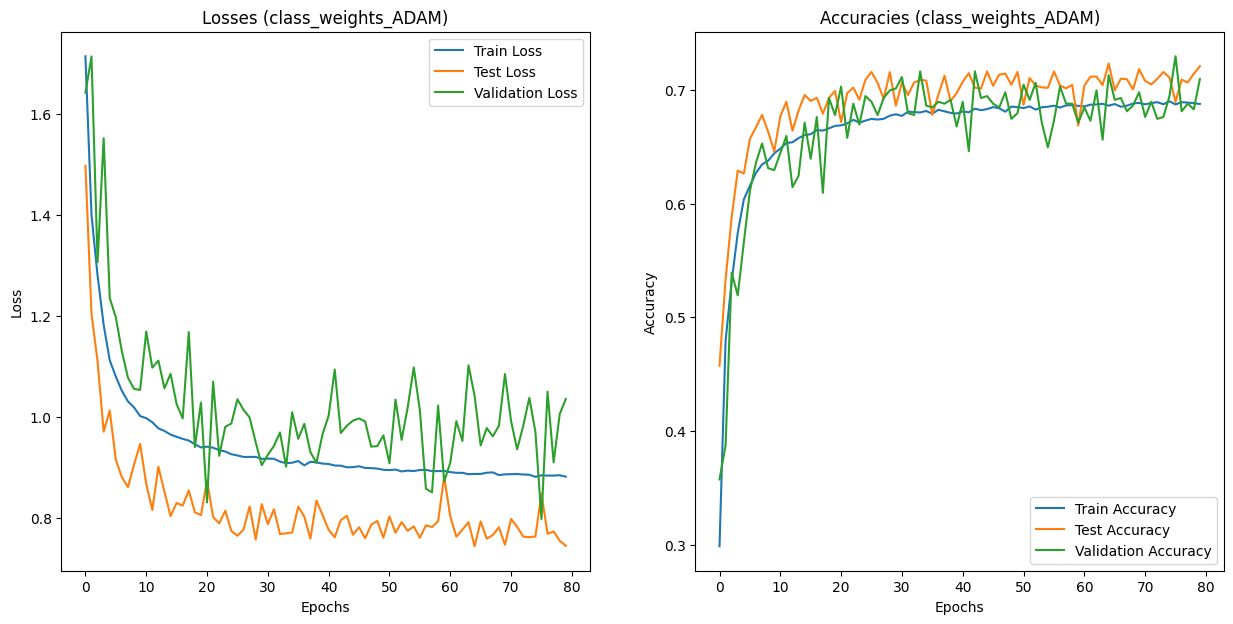

In [7]:
file_name = f"{output_path}/{experiment_name}/learning_curve.png"

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_losses, label="Train Loss")
plt.plot(range(num_epochs), test_losses, label="Test Loss")
plt.plot(range(num_epochs), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"Losses ({experiment_name})")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), train_accuracies, label="Train Accuracy")
plt.plot(range(num_epochs), test_accuracies, label="Test Accuracy")
plt.plot(range(num_epochs), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f"Accuracies ({experiment_name})")
plt.legend()

ax = plt.gca()
ax.set_xlim([0, num_epochs])
ax.set_ylim([0, 1])

plt.savefig(file_name, dpi=400, bbox_inches="tight", pad_inches=0.1)
plt.show()

In [8]:
df = pd.DataFrame(
    {
        "Epoch": range(
            1, num_epochs + 1
        ),  # change this number after '(1, _)' to num_epochs+1
        "Train Loss": train_losses,
        "Test Loss": test_losses,
        "Validation Loss": val_losses,
        "Train Accuracy": train_accuracies,
        "Test Accuracy": test_accuracies,
        "Validation Accuracy": val_accuracies,
    }
)
df.to_csv(
    f"{output_path}/{experiment_name}/result.csv",
    index=False,
)